# Facial Recognition Evaluation Notebook

This notebook adds **visualization** and **evaluation metrics** for the ANN face recognition pipeline used in `app.py`.

It will:
- Load face samples from `captures/dataset`
- Visualize class distribution and sample images
- Train an ANN model on a train split
- Evaluate on a held-out test split
- Plot a confusion matrix

In [19]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

plt.style.use("seaborn-v0_8")
np.random.seed(42)

PROJECT_ROOT = Path.cwd()
CAPTURES_DIR = PROJECT_ROOT / "captures"
DATASET_DIR = CAPTURES_DIR / "dataset"

INPUT_W, INPUT_H = 100, 100
INPUT_SIZE = INPUT_W * INPUT_H

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset dir:  {DATASET_DIR}")

Project root: c:\CODING\PYTHON\ML\FacialDetectionCamera
Dataset dir:  c:\CODING\PYTHON\ML\FacialDetectionCamera\captures\dataset


In [20]:
def load_dataset(dataset_dir: Path, image_size: tuple[int, int] = (100, 100)):
    samples = []
    targets = []
    label_names = []
    preview_images = {}

    if not dataset_dir.exists():
        raise FileNotFoundError(f"Dataset folder not found: {dataset_dir}")

    for person_dir in sorted(dataset_dir.iterdir()):
        if not person_dir.is_dir():
            continue

        label_index = len(label_names)
        label_names.append(person_dir.name)

        image_files = sorted(person_dir.glob("*.png"))
        for i, image_file in enumerate(image_files):
            img = cv2.imread(str(image_file), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, image_size, interpolation=cv2.INTER_AREA)
            vector = img.astype(np.float32).reshape(-1) / 255.0
            samples.append(vector)
            targets.append(label_index)

            if i == 0:
                preview_images[person_dir.name] = img

    if not samples:
        raise ValueError("No training samples were found in the dataset directory.")

    X = np.array(samples, dtype=np.float32)
    y = np.array(targets, dtype=np.int32)
    return X, y, label_names, preview_images


X, y, label_names, preview_images = load_dataset(DATASET_DIR, (INPUT_W, INPUT_H))

print(f"Classes: {len(label_names)} -> {label_names}")
print(f"Samples: {len(X)}")
print("Samples per class:")
for idx, name in enumerate(label_names):
    print(f"  {name:20s} : {(y == idx).sum()}")

Classes: 3 -> ['Anusha', 'Bhavadharani', 'Dhanya']
Samples: 13
Samples per class:
  Anusha               : 5
  Bhavadharani         : 4
  Dhanya               : 4


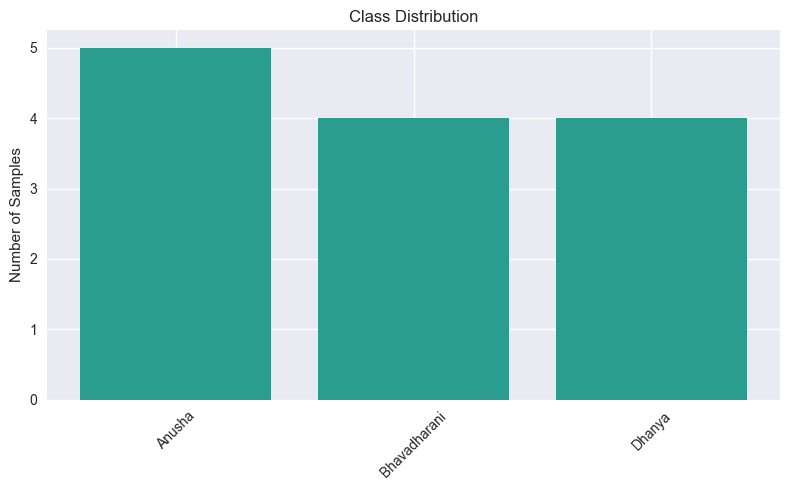

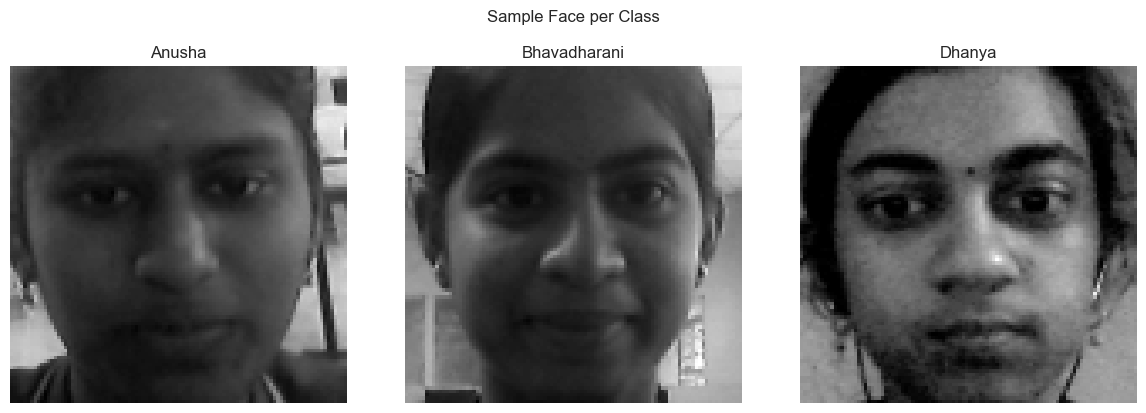

In [21]:
class_counts = np.array([(y == i).sum() for i in range(len(label_names))])

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(label_names, class_counts, color="#2A9D8F")
ax.set_title("Class Distribution")
ax.set_ylabel("Number of Samples")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

show_names = label_names[: min(6, len(label_names))]
cols = min(3, len(show_names))
rows = int(np.ceil(len(show_names) / cols))

fig, axs = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axs = np.array(axs).reshape(-1)

for i, ax in enumerate(axs):
    if i < len(show_names):
        name = show_names[i]
        ax.imshow(preview_images[name], cmap="gray")
        ax.set_title(name)
        ax.axis("off")
    else:
        ax.axis("off")

fig.suptitle("Sample Face per Class", y=1.02)
plt.tight_layout()
plt.show()

In [22]:
if len(label_names) < 2:
    raise ValueError("Need at least 2 classes for evaluation. Add samples for more people.")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y,
)

num_classes = len(label_names)
y_train_one_hot = np.zeros((len(y_train), num_classes), dtype=np.float32)
y_train_one_hot[np.arange(len(y_train)), y_train] = 1.0

ann = cv2.ml.ANN_MLP_create()
ann.setLayerSizes(np.array([INPUT_SIZE, 128, num_classes], dtype=np.int32))
ann.setActivationFunction(cv2.ml.ANN_MLP_SIGMOID_SYM, 1.0, 1.0)
ann.setTrainMethod(cv2.ml.ANN_MLP_BACKPROP, 0.001, 0.1)
ann.setTermCriteria((cv2.TERM_CRITERIA_MAX_ITER | cv2.TERM_CRITERIA_EPS, 400, 1e-4))

ok = ann.train(X_train, cv2.ml.ROW_SAMPLE, y_train_one_hot)
print(f"Training success: {ok}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

Training success: True
Train samples: 9, Test samples: 4


In [23]:
_, test_outputs = ann.predict(X_test)
y_pred = np.argmax(test_outputs, axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro",
    zero_division=0,
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0,
)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision (macro)  : {precision_macro:.4f}")
print(f"Recall (macro)     : {recall_macro:.4f}")
print(f"F1-score (macro)   : {f1_macro:.4f}")
print(f"Precision (weighted): {precision_weighted:.4f}")
print(f"Recall (weighted)   : {recall_weighted:.4f}")
print(f"F1-score (weighted) : {f1_weighted:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

Accuracy           : 0.5000
Precision (macro)  : 0.3333
Recall (macro)     : 0.5000
F1-score (macro)   : 0.3889
Precision (weighted): 0.3750
Recall (weighted)   : 0.5000
F1-score (weighted) : 0.4167

Classification Report:
              precision    recall  f1-score   support

      Anusha       0.50      0.50      0.50         2
Bhavadharani       0.00      0.00      0.00         1
      Dhanya       0.50      1.00      0.67         1

    accuracy                           0.50         4
   macro avg       0.33      0.50      0.39         4
weighted avg       0.38      0.50      0.42         4



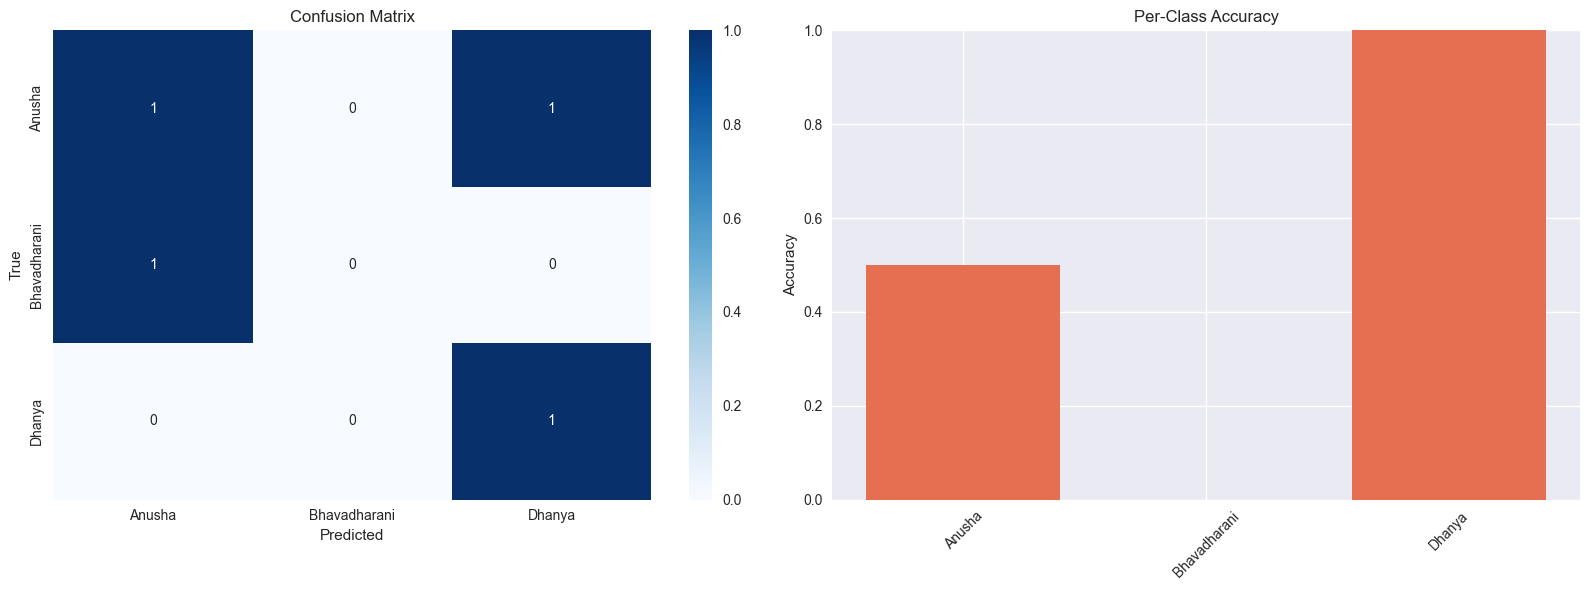

In [24]:
cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(label_names)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

class_acc = np.divide(cm.diagonal(), cm.sum(axis=1), out=np.zeros(len(label_names), dtype=float), where=cm.sum(axis=1) > 0)
axes[1].bar(label_names, class_acc, color="#E76F51")
axes[1].set_ylim(0, 1.0)
axes[1].set_title("Per-Class Accuracy")
axes[1].set_ylabel("Accuracy")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()